Compute mean connectivity from HCP7T dataset

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [3]:
# on work Mac Studio
'''
lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tians3_cort-carpet',
                         'atlas-custom_subcort-tians3_cort-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])
'''

"\nlut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',\n                         'atlas-custom_subcort-tians3_cort-carpet',\n                         'atlas-custom_subcort-tians3_cort-carpet_lut.tsv')\n\nregion_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])\n"

In [4]:
region_list = ['PUT-VA-lh',
 'PUT-DA-lh',
 'PUT-VP-lh',
 'PUT-DP-lh',
 'CAU-VA-lh',
 'CAU-DA-lh',
 'pCAU-lh',
 'PUT-VA-rh',
 'PUT-DA-rh',
 'PUT-VP-rh',
 'PUT-DP-rh',
 'CAU-VA-rh',
 'CAU-DA-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp']

In [5]:
region_list

['PUT-VA-lh',
 'PUT-DA-lh',
 'PUT-VP-lh',
 'PUT-DP-lh',
 'CAU-VA-lh',
 'CAU-DA-lh',
 'pCAU-lh',
 'PUT-VA-rh',
 'PUT-DA-rh',
 'PUT-VP-rh',
 'PUT-DP-rh',
 'CAU-VA-rh',
 'CAU-DA-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp']

In [6]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')
#data_dir = os.path.join('/Users/dsj3886/Library/CloudStorage/',
#                        'OneDrive/data/hcp_7T_mrtrix3')
print('data_dir:', data_dir)

data_dir: /Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/


## Read in participant connectivity matrices

In [7]:
'''conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tians3_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))
'''
conn_files = sorted(glob(data_dir + 
                         '/sub-*_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

In [8]:
print('number of files =', len(conn_files))
print(conn_files)

number of files = 100
['/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-100610_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-102311_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-102816_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-104416_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-105923_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-108323_streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/sub-109123_streamlines_alg-iFOD2_nsl-10mil_connec

In [9]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0            1            2            3            4   \
0   3860.860893  2255.435563   499.597474    18.188766   530.309088   
1   2255.435563  2170.985591   892.808425  1744.173615    14.790018   
2    499.597474   892.808425  1324.041865   605.882095    14.589335   
3     18.188766  1744.173615   605.882095  1743.920533     0.000000   
4    530.309088    14.790018    14.589335     0.000000  1584.676687   
5    420.541497  1192.021696   114.390596   174.212943  4082.607249   
6     21.585875   807.142970   109.800144  1016.695622   358.712312   
7     33.942493    13.376352    38.762449     0.000000    17.562279   
8      9.292955    23.725615    19.940405     8.472162     7.323464   
9     17.065034    31.899341    98.722855    16.445323     1.385063   
10     0.287141    56.109286     8.456884    65.554573     0.678034   
11     7.235478     0.594683     3.744791     0.266873    12.689611   
12     5.294243    11.605751     2.476211     3.571007     2.079493   
13    

In [10]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [11]:
np.shape(connmats)

(100, 24, 24)

In [12]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 8631.29392627,  5523.38818358,  7036.72913972, ...,
         3789.55338588,  3634.97988841,  6551.33640099],
       [ 9805.02082975,  5161.86478095,  6537.11843434, ...,
         4340.19317251,  4857.85015437,  4252.64530816],
       [11826.90823728, 11537.77035391, 14674.24452339, ...,
        10272.27009378, 11164.4060273 , 18000.23163895],
       ...,
       [53652.38690144, 51595.26494971, 62103.47678675, ...,
        41626.68092059, 45294.24164437, 38247.49656543],
       [21766.36793911, 13567.40311891, 19380.58447327, ...,
        25477.59347066,  9238.49164583, 17201.52354977],
       [56647.28237627, 50954.11980428, 63311.55079417, ...,
        54103.9955786 , 50458.34097642, 36842.36158867]])

## Compute mean streamline count per ROI

In [13]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 5188.61409372  5264.39992549 10116.42833909  5438.3899538
  3496.80047986  5316.44917203  4803.67603114  7417.48202977
  6695.89308392 10421.03562521  6643.54590335  3523.42330657
  5671.97058714  6377.81020724 28013.80308517 31410.28737724
 47712.19511167 26481.42788169 38633.05719553 26688.32042955
 26141.96766473 41723.78065983 15683.77258772 46461.44642816]
(24,)


In [14]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[2.21414473e+03 1.04794639e+03 4.17962027e+02 3.33164177e+01
  5.43597975e+02 3.01392560e+02 1.93814816e+01 8.12746715e+00
  1.98376778e+00 3.28530572e+00 1.48648854e-01 6.13028304e+00
  2.93451251e+00 7.07442122e-01 9.23419785e+00 5.30481880e+02
  2.72507837e+01 1.01135933e+01 8.25665484e+00 4.34837051e-02
  2.08804205e+00 2.13436586e-02 3.30015305e-02 3.21035655e-02]
 [1.04794639e+03 1.00159478e+03 6.02391580e+02 1.09195086e+03
  9.06385787e+00 4.52422187e+02 2.88764292e+02 2.91926460e+00
  7.73293001e+00 3.89720261e+00 1.09467213e+01 1.00973120e+00
  1.44739067e+01 1.71153272e+01 8.02037775e+01 4.36703785e+02
  1.48238428e+02 1.50421262e+01 3.06990418e+01 2.58422588e-02
  1.19189911e+00 3.49248278e-02 7.90586367e-03 2.31629385e-02]
 [4.17962027e+02 6.02391580e+02 1.10034405e+03 8.05756131e+02
  4.46189216e+00 9.25198911e+01 1.84884461e+02 8.13841818e+00
  3.34524816e+00 2.28234951e+01 5.89815258e+00 1.73694683e+00
  3.31982389e+00 7.74465938e+00 2.61445782e+03 2.91010001e+03
  1.04

In [15]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [16]:
mean_df

,mean_slcount,seed,PUT-VA-lh,PUT-DA-lh,PUT-VP-lh,PUT-DP-lh,CAU-VA-lh,CAU-DA-lh,pCAU-lh,PUT-VA-rh,...,L-HG,L-PP,L-PT,L-STGa,L-STGp,R-HG,R-PP,R-PT,R-STGa,R-STGp
0,5188.614094,PUT-VA-lh,2214.144728,1047.946393,417.962027,33.316418,543.597975,301.392560,19.381482,8.127467,...,9.234198,530.481880,27.250784,10.113593,8.256655,0.043484,2.088042,0.021344,0.033002,0.032104
1,5264.399925,PUT-DA-lh,1047.946393,1001.594776,602.391580,1091.950865,9.063858,452.422187,288.764292,2.919265,...,80.203777,436.703785,148.238428,15.042126,30.699042,0.025842,1.191899,0.034925,0.007906,0.023163
2,10116.428339,PUT-VP-lh,417.962027,602.391580,1100.344050,805.756131,4.461892,92.519891,184.884461,8.138418,...,2614.457821,2910.100010,1041.795568,181.412698,87.593987,3.349422,4.920844,10.758470,0.086792,0.625949
3,5438.389954,PUT-DP-lh,33.316418,1091.950865,805.756131,1302.925137,0.564204,63.748378,550.572744,0.059222,...,298.118901,1019.963857,160.172666,32.771076,35.496395,0.011784,2.244307,0.027591,0.000000,0.000000
4,3496.800480,CAU-VA-lh,543.597975,9.063858,4.461892,0.564204,1052.104105,1585.685667,263.582161,3.981515,...,0.278303,1.952361,0.952266,0.038954,0.158246,0.036876,1.116567,0.203480,0.005081,0.028724
5,5316.449172,CAU-DA-lh,301.392560,452.422187,92.519891,63.748378,1585.685667,1560.973723,1086.939196,1.864049,...,4.992315,44.070434,14.576166,2.698748,2.112593,0.159002,0.989582,0.431399,0.008198,0.012849
6,4803.676031,pCAU-lh,19.381482,288.764292,184.884461,550.572744,263.582161,1086.939196,2130.178740,0.499550,...,6.814211,80.240833,21.147245,2.878418,5.957895,0.993423,4.810105,5.989047,0.036933,0.080762
7,7417.482030,PUT-VA-rh,8.127467,2.919265,8.138418,0.059222,3.981515,1.864049,0.499550,2873.034807,...,0.021047,2.668628,0.052190,0.065473,0.004356,17.434982,1570.977675,44.567385,15.563110,28.073672
8,6695.893084,PUT-DA-rh,1.983768,7.732930,3.345248,4.145315,0.695384,14.481784,16.413947,1487.051048,...,0.012065,0.688049,0.031034,0.068051,0.002300,169.327094,484.592446,428.627442,13.213966,154.521056
9,10421.035625,PUT-VP-rh,3.285306,3.897203,22.823495,4.246108,0.907927,2.772471,7.827870,565.900435,...,3.008329,3.756558,6.292822,0.079476,0.038892,2630.043552,2137.709593,1453.031755,141.391692,393.810202


In [17]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Oct')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity.txt')
#os.makedirs(out_dir, exist_ok=True)
#mean_df.to_csv(out_fpath, sep='\t', index=False)

In [18]:
out_dir

'/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Oct'

### Plot distributions

In [19]:
import seaborn as sns

In [20]:
connmats.shape

(100, 24, 24)

<Axes: >

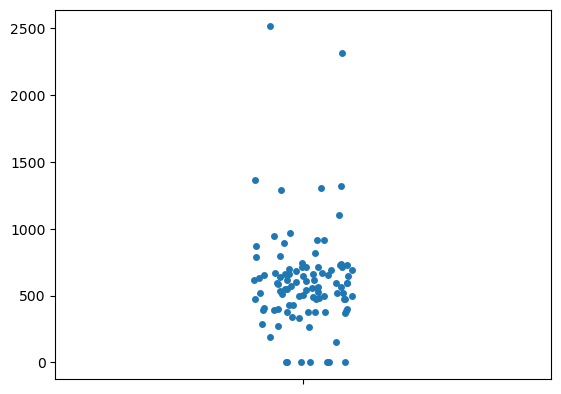

In [21]:
sns.stripplot(connmats[:,1,2])

## Combine separate participants into single dataframe

**TO DO**

Step 1: create pd DataFrame for each participant

Step 2: keep rows = striatum, columns = cortex; drop cortex rows, striatum columns

Step 3: add Rostral/Caudal column, aligned with striatum ROI

Step 4: merge all participants' dataframes

Step 5: run ANOVA with Rostral/Caudal as feature

In [22]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [23]:
striatum_rois = [r for r in region_list if r.startswith(('PUT', 'CAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'][0]
    filtered_df_list.append(sub_df)

/var/folders/5g/l5zc58vs5y17h1lbzp_7g3_40000gq/T/ipykernel_17514/1488223902.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sub_df['participant_id'] = df['participant_id'][0]
/var/folders/5g/l5zc58vs5y17h1lbzp_7g3_40000gq/T/ipykernel_17514/1488223902.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sub_df['participant_id'] = df['participant_id'][0]
/var/folders/5g/l5zc58vs5y17h1lbzp_7g3_40000gq/T/ipykernel_17514/1488223902.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To 

In [68]:
rostral_caudal_map = {
    'PUT-VA-lh': 'Rostral', 'PUT-DA-lh': 'Rostral', 
    'PUT-VP-lh': 'Caudal', 'PUT-DP-lh': 'Caudal',
    'CAU-VA-lh': 'Rostral', 'CAU-DA-lh': 'Rostral', 
    'pCAU-lh': 'Caudal',
    'PUT-VA-rh': 'Rostral', 'PUT-DA-rh': 'Rostral', 
    'PUT-VP-rh': 'Caudal', 'PUT-DP-rh': 'Caudal',
    'CAU-VA-rh': 'Rostral', 'CAU-DA-rh': 'Rostral', 
    'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [154]:
caudate_putamen_map = {
    'PUT-VA-lh': 'Putamen', 'PUT-DA-lh': 'Putamen', 
    'PUT-VP-lh': 'Putamen', 'PUT-DP-lh': 'Putamen',
    'CAU-VA-lh': 'Caudate', 'CAU-DA-lh': 'Caudate', 
    'pCAU-lh': 'Caudate',
    'PUT-VA-rh': 'Putamen', 'PUT-DA-rh': 'Putamen', 
    'PUT-VP-rh': 'Putamen', 'PUT-DP-rh': 'Caudate',
    'CAU-VA-rh': 'Caudate', 'CAU-DA-rh': 'Caudate', 
    'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [155]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [156]:

# Melt to long format
long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [157]:
long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,PUT-VA-lh,Rostral,Putamen,L-HG,10.443239
1,0,PUT-DA-lh,Rostral,Putamen,L-HG,55.391193
2,0,PUT-VP-lh,Caudal,Putamen,L-HG,2866.256197
3,0,PUT-DP-lh,Caudal,Putamen,L-HG,237.990263
4,0,CAU-VA-lh,Rostral,Caudate,L-HG,0.485812


In [158]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

long_df['striatum_hemisphere'] = long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
long_df['cortex_hemisphere'] = long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
long_df = long_df[long_df['striatum_hemisphere'] == long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
long_df['hemisphere'] = long_df['striatum_hemisphere']
long_df['Striatum_ROI'] = long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
long_df['Cortex_ROI'] = long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [159]:
long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,PUT-VA,Rostral,Putamen,HG,10.443239,Left,Left,Left
1,0,PUT-DA,Rostral,Putamen,HG,55.391193,Left,Left,Left
2,0,PUT-VP,Caudal,Putamen,HG,2866.256197,Left,Left,Left
3,0,PUT-DP,Caudal,Putamen,HG,237.990263,Left,Left,Left
4,0,CAU-VA,Rostral,Caudate,HG,0.485812,Left,Left,Left


## Across-participant statistics

In [160]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

### Caudate–Putamen

In [175]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,520.9499,1.0000,99.0000,0.0000
Cortex_ROI,418.4153,4.0000,396.0000,0.0000
hemisphere,158.3456,1.0000,99.0000,0.0000
Caudate_Putamen:Cortex_ROI,351.3747,4.0000,396.0000,0.0000
Caudate_Putamen:hemisphere,3.0801,1.0000,99.0000,0.0823
Cortex_ROI:hemisphere,36.9572,4.0000,396.0000,0.0000
Caudate_Putamen:Cortex_ROI:hemisphere,9.6221,4.0000,396.0000,0.0000


In [166]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,T,dof,p-unc,p-corr,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-22.791108,99.0,3.589144e-41,NaN,6.084e+37
1,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
2,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
3,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
4,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
5,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
6,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
7,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
8,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
9,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29


In [167]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
1,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
2,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
3,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
4,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
5,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
6,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
7,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
8,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29
9,Cortex_ROI,-,STGa,STGp,-12.573800,99.0,3.088936e-22,3.088936e-22,1.454e+19


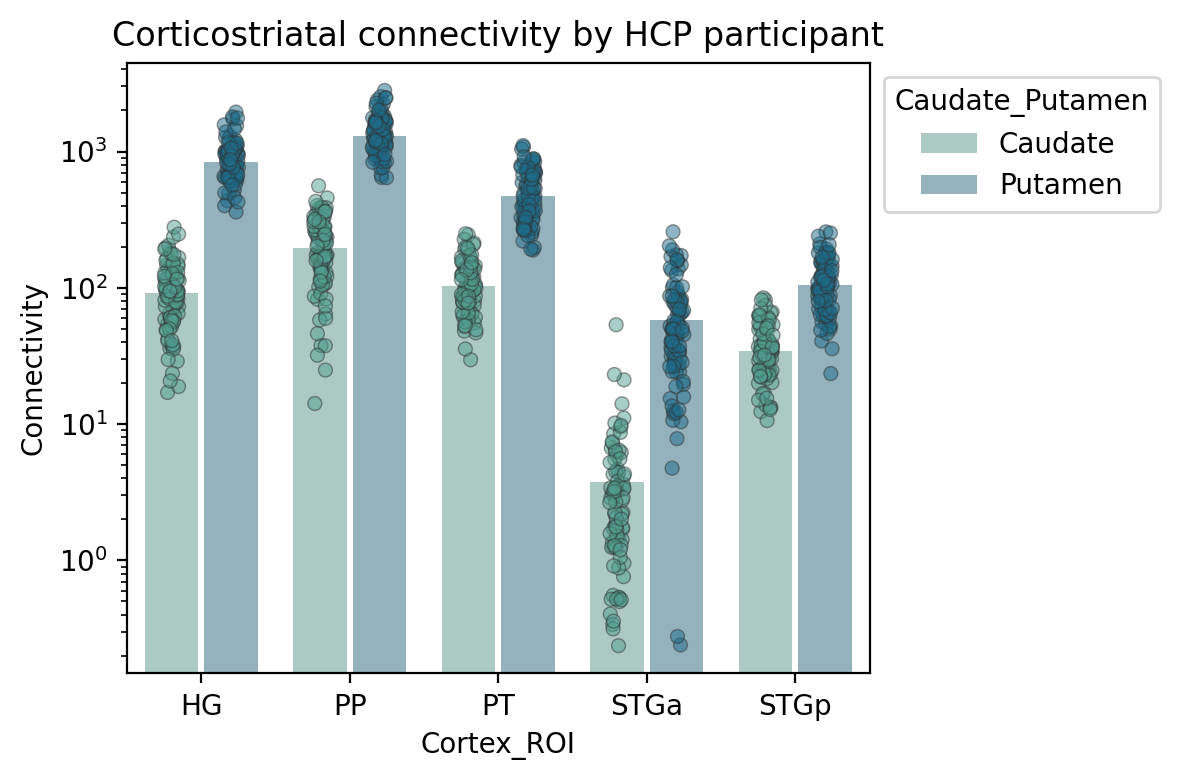

In [168]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


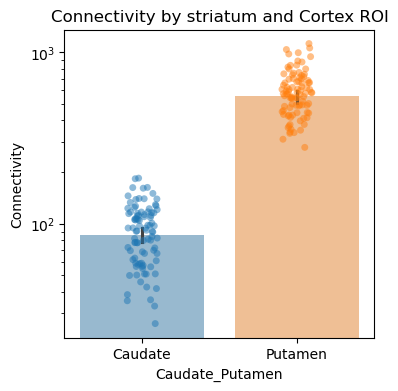

In [170]:
df_collapsed = long_df.groupby(["participant_id", 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by striatum and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [171]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Caudate_Putamen',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
1,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
2,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
3,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
4,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
5,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
6,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
7,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
8,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29
9,Cortex_ROI,-,STGa,STGp,-12.573800,99.0,3.088936e-22,3.088936e-22,1.454e+19


In [172]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen','A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,T,dof,p-unc,p-corr,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-22.791108,99.0,3.589144e-41,NaN,6.084e+37
1,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
2,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
3,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
4,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
5,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
6,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
7,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
8,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
9,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29


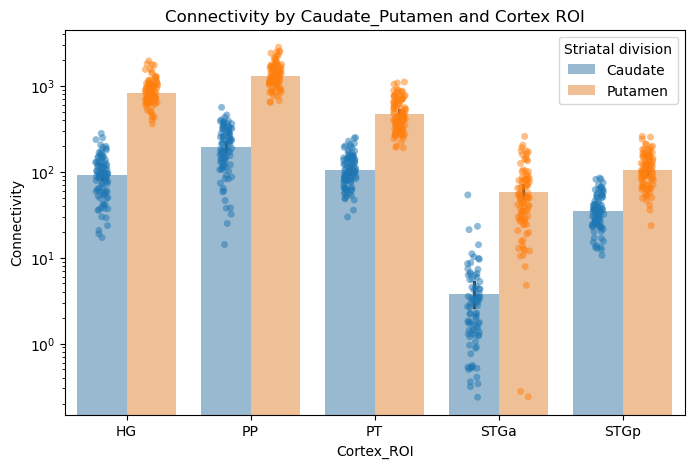

In [173]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Caudate_Putamen and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere,-,Left,Right,-7.434721,99.0,3.817840e-11,NaN,2.326e+08
1,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
2,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
3,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
4,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
5,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
6,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
7,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
8,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
9,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29


In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
1,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
2,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
3,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
4,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
5,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
6,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
7,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
8,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29
9,Cortex_ROI,-,STGa,STGp,-12.573800,99.0,3.088936e-22,3.088936e-22,1.454e+19


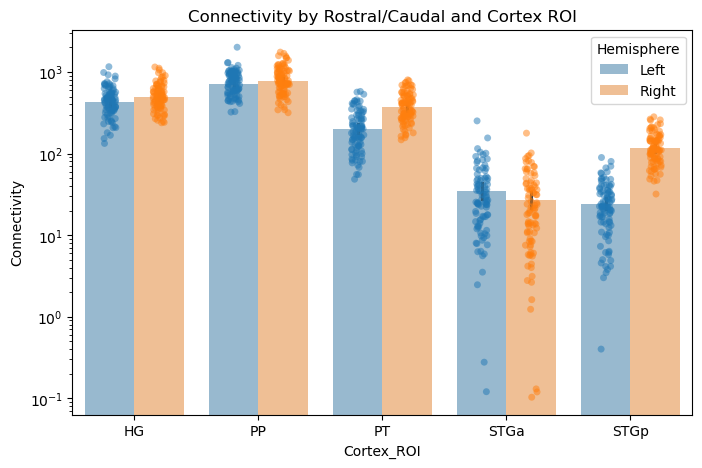

In [ ]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Striatum_ROI,-,CAU-DA,CAU-VA,9.084653,99.0,1.084086e-14,1.264767e-14,6.314e+11
1,Striatum_ROI,-,CAU-DA,PUT-DA,-17.554549,99.0,3.652613e-32,6.973169e-32,8.121e+28
2,Striatum_ROI,-,CAU-DA,PUT-DP,-22.347592,99.0,1.835573e-40,9.506255e-40,1.217e+37
3,Striatum_ROI,-,CAU-DA,PUT-VA,-12.603231,99.0,2.676467e-22,3.747054e-22,1.673e+19
4,Striatum_ROI,-,CAU-DA,PUT-VP,-22.653625,99.0,5.938729e-41,6.151208e-40,3.703e+37
5,Striatum_ROI,-,CAU-DA,pCAU,-6.125403,99.0,1.838354e-08,1.930272e-08,6.172e+05
6,Striatum_ROI,-,CAU-VA,PUT-DA,-18.169427,99.0,2.688972e-33,5.646841e-33,1.059e+30
7,Striatum_ROI,-,CAU-VA,PUT-DP,-22.291083,99.0,2.263394e-40,9.506255e-40,9.897e+36
8,Striatum_ROI,-,CAU-VA,PUT-VA,-13.284003,99.0,9.954626e-24,1.493194e-23,4.206e+20
9,Striatum_ROI,-,CAU-VA,PUT-VP,-22.723232,99.0,4.601005e-41,6.151208e-40,4.763e+37


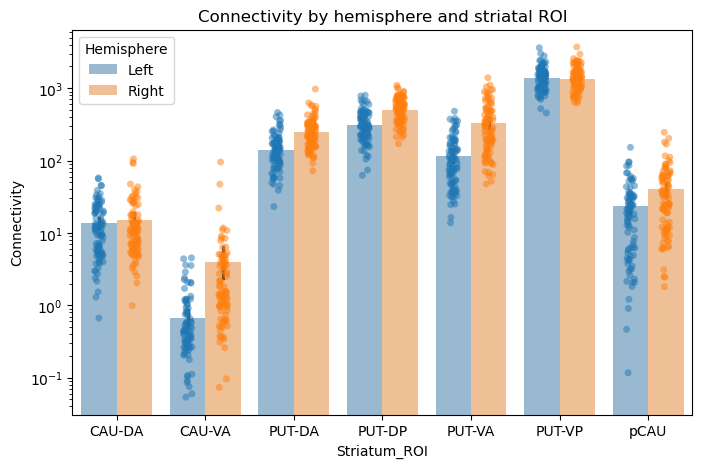

In [ ]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

### Rostral–caudal

In [144]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Rostral_Caudal,486.3278,1.0000,99.0000,0.0000
hemisphere,44.6311,1.0000,99.0000,0.0000
Cortex_ROI,421.2717,4.0000,396.0000,0.0000
Rostral_Caudal:hemisphere,0.7637,1.0000,99.0000,0.3843
Rostral_Caudal:Cortex_ROI,222.6133,4.0000,396.0000,0.0000
hemisphere:Cortex_ROI,21.8383,4.0000,396.0000,0.0000
Rostral_Caudal:hemisphere:Cortex_ROI,68.3252,4.0000,396.0000,0.0000


In [117]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere,-,Left,Right,-6.680650,99.0,1.405735e-09,NaN,7.24e+06
1,Rostral_Caudal,-,Caudal,Rostral,22.052841,99.0,5.496347e-40,NaN,4.126e+36
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,21.172463,99.0,1.542577e-38,3.085155e-38,1.541e+35
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,19.204912,99.0,3.699604e-35,3.699604e-35,7.203e+31


In [145]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,T,dof,p-unc,p-corr,BF10
0,Rostral_Caudal,-,Caudal,Rostral,22.052841,99.0,5.496347e-40,NaN,4.126e+36
1,hemisphere,-,Left,Right,-6.680650,99.0,1.405735e-09,NaN,7.24e+06
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,-3.371911,99.0,1.066034e-03,1.066034e-03,20.975
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,-10.331637,99.0,2.070122e-17,4.140243e-17,2.796e+14


In [118]:
long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,PUT-VA,Rostral,Putamen,HG,10.443239,Left,Left,Left
1,0,PUT-DA,Rostral,Putamen,HG,55.391193,Left,Left,Left
2,0,PUT-VP,Caudal,Putamen,HG,2866.256197,Left,Left,Left
3,0,PUT-DP,Caudal,Putamen,HG,237.990263,Left,Left,Left
4,0,CAU-VA,Rostral,Caudate,HG,0.485812,Left,Left,Left


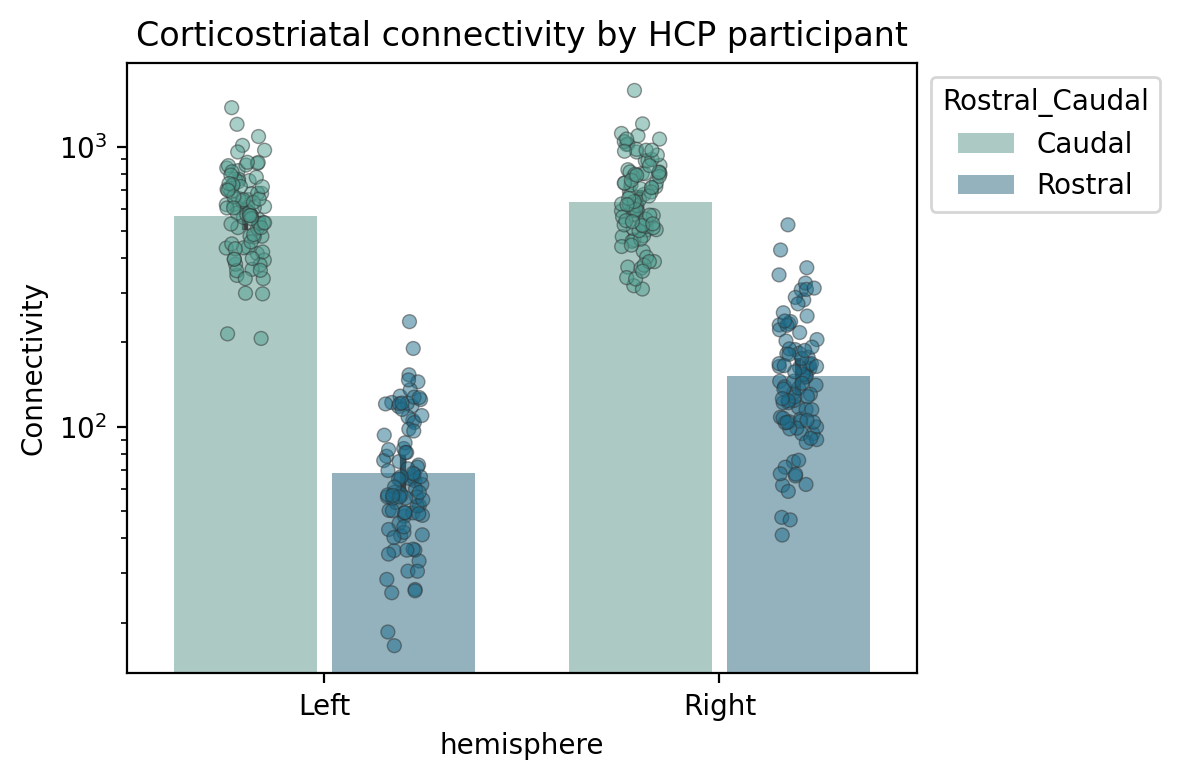

In [ ]:
df_collapsed = long_df.groupby(["participant_id", 'hemisphere', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


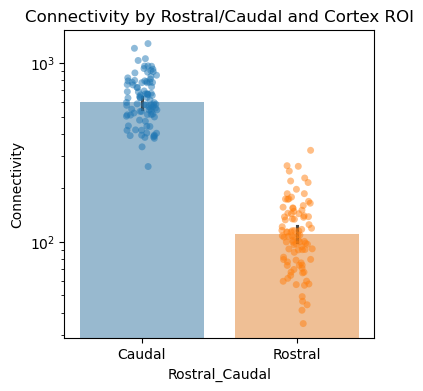

In [122]:
df_collapsed = long_df.groupby(["participant_id", 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [136]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Cortex_ROI,-,HG,PP,-11.866385,99.0,9.910199e-21,9.910199e-21,4.88e+17
1,Cortex_ROI,-,HG,PT,13.622078,99.0,1.976355e-24,2.470443e-24,2.052e+21
2,Cortex_ROI,-,HG,STGa,21.856788,99.0,1.146147e-39,3.820489e-39,1.999e+36
3,Cortex_ROI,-,HG,STGp,20.752203,99.0,7.821727e-38,1.955432e-37,3.111e+34
4,Cortex_ROI,-,PP,PT,18.748305,99.0,2.408841e-34,4.014734e-34,1.138e+31
5,Cortex_ROI,-,PP,STGa,23.841071,99.0,8.204992e-43,8.204992e-42,2.528e+39
6,Cortex_ROI,-,PP,STGp,22.779495,99.0,3.744814e-41,1.872407e-40,5.835e+37
7,Cortex_ROI,-,PT,STGa,18.996465,99.0,8.673678e-35,1.734736e-34,3.112e+31
8,Cortex_ROI,-,PT,STGp,17.983976,99.0,5.876582e-33,8.395116e-33,4.903e+29
9,Cortex_ROI,-,STGa,STGp,-12.177243,99.0,2.147239e-21,2.385822e-21,2.179e+18


In [146]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Rostral_Caudal', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Rostral_Caudal','A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,T,dof,p-unc,p-corr,BF10
0,Rostral_Caudal,-,Caudal,Rostral,22.052841,99.0,5.496347e-40,NaN,4.126e+36
1,Cortex_ROI,-,HG,PP,-11.866385,99.0,9.910199e-21,9.910199e-21,4.88e+17
2,Cortex_ROI,-,HG,PT,13.622078,99.0,1.976355e-24,2.470443e-24,2.052e+21
3,Cortex_ROI,-,HG,STGa,21.856788,99.0,1.146147e-39,3.820489e-39,1.999e+36
4,Cortex_ROI,-,HG,STGp,20.752203,99.0,7.821727e-38,1.955432e-37,3.111e+34
5,Cortex_ROI,-,PP,PT,18.748305,99.0,2.408841e-34,4.014734e-34,1.138e+31
6,Cortex_ROI,-,PP,STGa,23.841071,99.0,8.204992e-43,8.204992e-42,2.528e+39
7,Cortex_ROI,-,PP,STGp,22.779495,99.0,3.744814e-41,1.872407e-40,5.835e+37
8,Cortex_ROI,-,PT,STGa,18.996465,99.0,8.673678e-35,1.734736e-34,3.112e+31
9,Cortex_ROI,-,PT,STGp,17.983976,99.0,5.876582e-33,8.395116e-33,4.903e+29


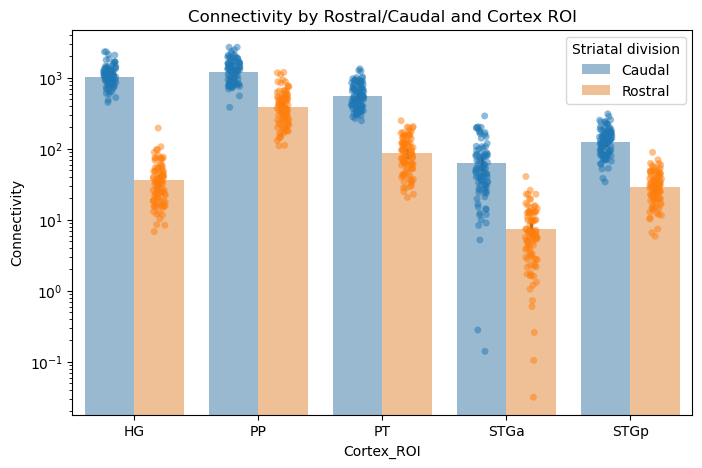

In [139]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere,-,Left,Right,-7.434721,99.0,3.817840e-11,NaN,2.326e+08
1,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
2,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
3,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
4,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
5,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
6,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
7,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
8,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
9,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29


In [147]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Cortex_ROI,-,HG,PP,-13.282636,99.0,1.002012e-23,1.252515e-23,4.179e+20
1,Cortex_ROI,-,HG,PT,13.063941,99.0,2.870158e-23,3.189064e-23,1.49e+20
2,Cortex_ROI,-,HG,STGa,21.801401,99.0,1.411727e-39,4.705758e-39,1.628e+36
3,Cortex_ROI,-,HG,STGp,20.627144,99.0,1.273076e-37,3.182689e-37,1.925e+34
4,Cortex_ROI,-,PP,PT,19.189137,99.0,3.945283e-35,7.890566e-35,6.761e+31
5,Cortex_ROI,-,PP,STGa,23.776186,99.0,1.032767e-42,1.032767e-41,2.015e+39
6,Cortex_ROI,-,PP,STGp,22.828178,99.0,3.134561e-41,1.567280e-40,6.954e+37
7,Cortex_ROI,-,PT,STGa,19.012170,99.0,8.132834e-35,1.355472e-34,3.316e+31
8,Cortex_ROI,-,PT,STGp,17.974916,99.0,6.106074e-33,8.722963e-33,4.722e+29
9,Cortex_ROI,-,STGa,STGp,-12.573800,99.0,3.088936e-22,3.088936e-22,1.454e+19


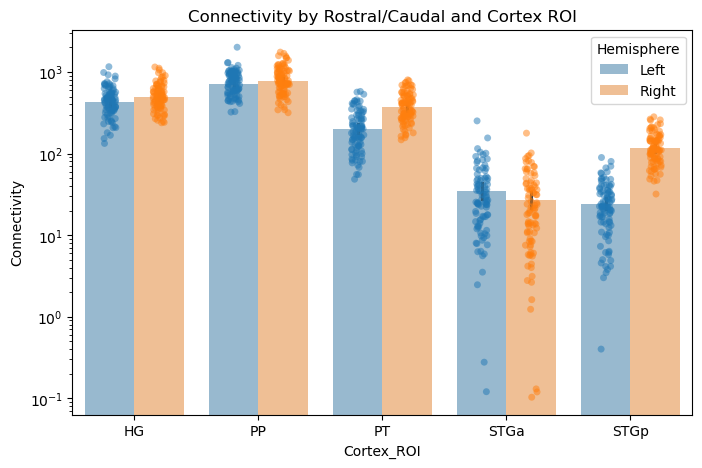

In [142]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [133]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p-unc,p-corr,BF10
0,Striatum_ROI,-,CAU-DA,CAU-VA,9.084653,99.0,1.084086e-14,1.264767e-14,6.314e+11
1,Striatum_ROI,-,CAU-DA,PUT-DA,-17.554549,99.0,3.652613e-32,6.973169e-32,8.121e+28
2,Striatum_ROI,-,CAU-DA,PUT-DP,-22.347592,99.0,1.835573e-40,9.506255e-40,1.217e+37
3,Striatum_ROI,-,CAU-DA,PUT-VA,-12.603231,99.0,2.676467e-22,3.747054e-22,1.673e+19
4,Striatum_ROI,-,CAU-DA,PUT-VP,-22.653625,99.0,5.938729e-41,6.151208e-40,3.703e+37
5,Striatum_ROI,-,CAU-DA,pCAU,-6.125403,99.0,1.838354e-08,1.930272e-08,6.172e+05
6,Striatum_ROI,-,CAU-VA,PUT-DA,-18.169427,99.0,2.688972e-33,5.646841e-33,1.059e+30
7,Striatum_ROI,-,CAU-VA,PUT-DP,-22.291083,99.0,2.263394e-40,9.506255e-40,9.897e+36
8,Striatum_ROI,-,CAU-VA,PUT-VA,-13.284003,99.0,9.954626e-24,1.493194e-23,4.206e+20
9,Striatum_ROI,-,CAU-VA,PUT-VP,-22.723232,99.0,4.601005e-41,6.151208e-40,4.763e+37


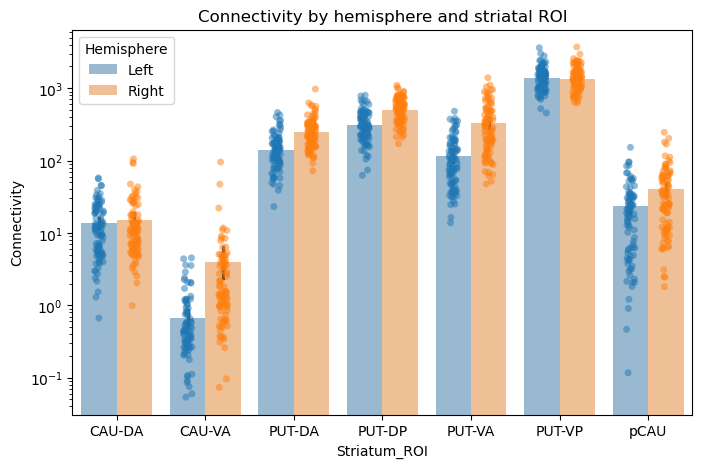

In [143]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()